In [30]:
import os
import numpy as np
import mne

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from mne.decoding import CSP

import matplotlib.pyplot as plt

In [2]:
data_folder = "../data/BCI_IV_2a"

subjects = [
    "A01T",
    "A02T",
    "A03T",
    "A04T",
    "A05T",
    "A06T",
    "A07T",
    "A08T",
    "A09T"
]

In [14]:
X_list = []
y_list = []

In [5]:
raws = {}   # store all raw objects


for subject in subjects:

    file_path = os.path.join(
        data_folder,
        subject + ".gdf"
    )

    print("Loading:", file_path)

    raw = mne.io.read_raw_gdf(
        file_path,
        preload=True
    )

    raws[subject] = raw

    print("Finished:", subject)

Loading: ../data/BCI_IV_2a\A01T.gdf
Extracting GDF parameters from ../data/BCI_IV_2a\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Finished: A01T
Loading: ../data/BCI_IV_2a\A02T.gdf
Extracting GDF parameters from ../data/BCI_IV_2a\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Finished: A02T
Loading: ../data/BCI_IV_2a\A03T.gdf
Extracting GDF parameters from ../data/BCI_IV_2a\A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


...

Finished: A07T
Loading: ../data/BCI_IV_2a\A08T.gdf
Extracting GDF parameters from ../data/BCI_IV_2a\A08T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Finished: A08T
Loading: ../data/BCI_IV_2a\A09T.gdf
Extracting GDF parameters from ../data/BCI_IV_2a\A09T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Finished: A09T


In [17]:
event_id = {
    "LEFT": 7,
    "RIGHT": 8,
    "FOOT": 9,
    "TONGUE": 10
}

In [18]:
for subject in subjects:

    print("====================")
    print("Processing:", subject)

    file_path = os.path.join(
        data_folder,
        subject + ".gdf"
    )

    # Load data
    raw = mne.io.read_raw_gdf(
        file_path,
        preload=True
    )

    # Keep EEG channels only (remove EOG)
    raw.pick_types(eeg=True)

    # Find events
    events, event_dict = mne.events_from_annotations(raw)

    print("Available events:", event_dict)


    # Keep only classes that exist in this subject
    available_events = {
        name: code
        for name, code in event_id.items()
        if code in events[:, 2]
    }

    print("Using classes:", available_events)


    # Create epochs
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True
    )


    X = epochs.get_data()
    y = epochs.events[:, -1]


    print("Subject X:", X.shape)
    print("Subject y:", y.shape)


    X_list.append(X)
    y_list.append(y)



# Combine all subjects
X_multi = np.concatenate(X_list, axis=0)
y_multi = np.concatenate(y_list, axis=0)


print("====================")
print("FINAL DATASET")
print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

print("Classes:")
print(np.unique(y_multi, return_counts=True))

Processing: A01T
Extracting GDF parameters from ../data/BCI_IV_2a\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Available events: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using classes: {'LEFT': 7, 'RIGHT': 8, 'FOOT': 9, 'TONGUE': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Subject X: (288, 25, 1001)
Subject y: (288,)
Processing: A02T
Extracting GDF parameters from ../data/BCI_IV_2a\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Available events: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using classes: {'LEFT': 7, 'RIGHT': 8, 'FOOT': 9, 'TONGUE': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Subject X: (288, 25, 1001)
Subject y: (288,)
Processing: A03T
Extracting GDF parameters from ../data/BCI_IV_2a\A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Available events: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using classes: {'LEFT': 7, 'RIGHT': 8, 'FOOT': 9, 'TONGUE': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Subject X: (288, 25, 1001)
Subject y: (288,)
Processing: A08T
Extracting GDF parameters from ../data/BCI_IV_2a\A08T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Available events: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using classes: {'LEFT': 7, 'RIGHT': 8, 'FOOT': 9, 'TONGUE': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Subject X: (288, 25, 1001)
Subject y: (288,)
Processing: A09T
Extracting GDF parameters from ../data/BCI_IV_2a\A09T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Available events: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using classes: {'LEFT': 7, 'RIGHT': 8, 'FOOT': 9, 'TONGUE': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Subject X: (288, 25, 1001)
Subject y: (288,)
FINAL DATASET
X_multi shape: (3312, 25, 1001)
y_multi shape: (3312,)
Classes:
(array([ 7,  8,  9, 10]), array([864, 864, 792, 792]))


In [19]:
print(raw.ch_names)

['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']


In [21]:
X_multi = X_multi[:, :22, :]
print(X_multi.shape)

(3312, 22, 1001)


In [22]:
X_filtered = X_multi.copy()

for i in range(X_filtered.shape[0]):
    X_filtered[i] = mne.filter.filter_data(
        X_filtered[i],
        sfreq=250,
        l_freq=8,
        h_freq=30,
        verbose=False
    )

print(X_filtered.shape)

(3312, 22, 1001)


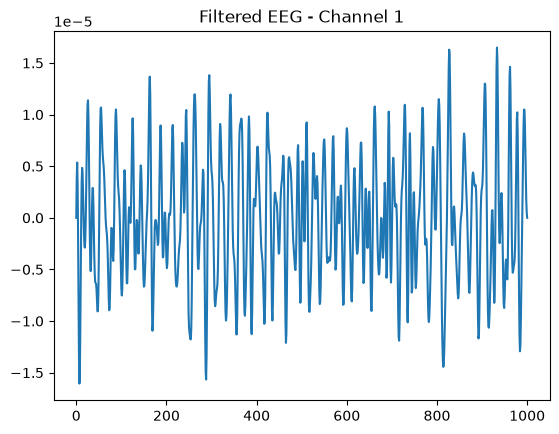

In [23]:
plt.plot(X_filtered[0,0])
plt.title("Filtered EEG - Channel 1")
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2649, 22, 1001)
X_test: (663, 22, 1001)
y_train: (2649,)
y_test: (663,)


In [25]:
csp = CSP(
    n_components=8,
    reg=None,
    log=True,
    norm_trace=False
)

# Fit only on training data
X_train_csp = csp.fit_transform(
    X_train,
    y_train
)

# Transform test data
X_test_csp = csp.transform(
    X_test
)


print("X_train CSP:", X_train_csp.shape)
print("X_test CSP:", X_test_csp.shape)

Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 22 dim * 4.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance using EMPIRICAL
Done.
X_train CSP: (2649, 8)
X_test CSP: (663, 8)


In [28]:
lda = LinearDiscriminantAnalysis()

lda.fit(
    X_train_csp,
    y_train
)


y_pred = lda.predict(
    X_test_csp
)


accuracy = accuracy_score(
    y_test,
    y_pred
)

print("CSP + LDA Accuracy:", accuracy*100, "%")


print(classification_report(
    y_test,
    y_pred
))

CSP + LDA Accuracy: 46.15384615384615 %
              precision    recall  f1-score   support

           7       0.51      0.47      0.49       173
           8       0.44      0.60      0.51       173
           9       0.42      0.47      0.44       159
          10       0.49      0.29      0.37       158

    accuracy                           0.46       663
   macro avg       0.47      0.46      0.45       663
weighted avg       0.47      0.46      0.46       663



In [31]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


svm.fit(
    X_train_csp,
    y_train
)


y_pred_svm = svm.predict(
    X_test_csp
)


accuracy = accuracy_score(
    y_test,
    y_pred_svm
)


print("CSP + RBF SVM Accuracy:", accuracy*100, "%")

CSP + RBF SVM Accuracy: 57.61689291101055 %


In [32]:
for n in [4,6,8,12,16]:

    csp = CSP(
        n_components=n,
        reg=None,
        log=True,
        norm_trace=False
    )

    X_train_csp = csp.fit_transform(
        X_train,
        y_train
    )

    X_test_csp = csp.transform(
        X_test
    )


    svm = SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    )

    svm.fit(
        X_train_csp,
        y_train
    )


    acc = svm.score(
        X_test_csp,
        y_test
    )

    print(
        n,
        "CSP components:",
        acc*100,
        "%"
    )

Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 22 dim * 4.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance using EMPIRICAL
Done.
4 CSP components: 47.963800904977376 %
Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 22 dim * 4.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance using EMPIRICAL
Done.
6 CSP components: 54.600301659125186 %
Co